*Loading* our **dataset**

In [2]:
from google.colab import files

uploaded=files.upload()

Saving KaggleV2-May-2016.csv to KaggleV2-May-2016.csv


Reviewing the Dataset

In [3]:
import pandas as pd
import numpy as np

df=pd.read_csv("KaggleV2-May-2016.csv")

print("Shape", df.shape)
print("Columns",df.columns)
print("info", df.info)
# print("Describe", df.describe())

df.isnull().sum()

Shape (110527, 14)
Columns Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')
info <bound method DataFrame.info of            PatientId  AppointmentID Gender          ScheduledDay  \
0       2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1       5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2       4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3       8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4       8.841186e+12        5642494      F  2016-04-29T16:07:23Z   
...              ...            ...    ...                   ...   
110522  2.572134e+12        5651768      F  2016-05-03T09:15:35Z   
110523  3.596266e+12        5650093      F  2016-05-03T07:27:33Z   
110524  1.557663e+13        5630692      F  2016-04-27T16:03:52Z   
110525  9.213493e+1

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


Check the **Target Values**

In [4]:
print(df['No-show'].value_counts())
print("\nPercentages:")
print(df['No-show'].value_counts(normalize=True) * 100)

No-show
No     88208
Yes    22319
Name: count, dtype: int64

Percentages:
No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64


Summary of Findings

In [5]:
print("Age min and max:", df['Age'].min(), "-", df['Age'].max())
print("\nHandcap unique values:", sorted(df['Handcap'].unique()))
print("\nAny duplicate rows?", df.duplicated().sum())

Age min and max: -1 - 115

Handcap unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Any duplicate rows? 0


Data **Cleaning**

Removing -1 age from dataset

In [6]:
df_clean=df.copy()
print("Before removing negative age:")
print(f"  Total rows: {len(df_clean)}")
print(f"  Minimum age: {df_clean['Age'].min()}")

df_clean=df_clean[df_clean['Age'] >= 0]

print("\nAfter removing negative age:")
print(f"  Total rows: {len(df_clean)}")
print(f"  Minimum age: {df_clean['Age'].min()}")


Before removing negative age:
  Total rows: 110527
  Minimum age: -1

After removing negative age:
  Total rows: 110526
  Minimum age: 0


Fixing mis spelled Column

In [7]:
df_clean=df_clean.rename(columns={'Hipertension': 'Hypertension'})
print("Column Renamed")

Column Renamed


Converting text to binary (0/1)

In [8]:
df_clean['NoShow'] = df_clean['No-show'].map({'No': 0, 'Yes': 1})

print("\nTarget variable converted:")
print(df_clean['NoShow'].value_counts())


Target variable converted:
NoShow
0    88207
1    22319
Name: count, dtype: int64


Covert **Data Columns**



In [10]:
print("Before conversion:")
print(f"  ScheduledDay type: {df_clean['ScheduledDay'].dtype}")
print(f"  AppointmentDay type: {df_clean['AppointmentDay'].dtype}")

df_clean['ScheduledDay'] = pd.to_datetime(df_clean['ScheduledDay'])
df_clean['AppointmentDay'] = pd.to_datetime(df_clean['AppointmentDay'])


print("\nAfter conversion:")
print(f"  ScheduledDay type: {df_clean['ScheduledDay'].dtype}")
print(f"  AppointmentDay type: {df_clean['AppointmentDay'].dtype}")





Before conversion:
  ScheduledDay type: datetime64[ns, UTC]
  AppointmentDay type: datetime64[ns, UTC]

After conversion:
  ScheduledDay type: datetime64[ns, UTC]
  AppointmentDay type: datetime64[ns, UTC]


Adding new **features** from existing ones

In [11]:
df_clean['WaitingDays'] = (df_clean['AppointmentDay'] - df_clean['ScheduledDay']).dt.days

print("1. WaitingDays created")
print(f"   Min: {df_clean['WaitingDays'].min()}")
print(f"   Max: {df_clean['WaitingDays'].max()}")
print(f"   Negative values: {(df_clean['WaitingDays'] < 0).sum()}")



1. WaitingDays created
   Min: -7
   Max: 178
   Negative values: 38567


In [12]:
# Look at some negative waiting days
negative_rows = df_clean[df_clean['WaitingDays'] < 0]

print("Number of negative rows:", len(negative_rows))
print("\nFirst 5 negative rows:")
print(negative_rows[['ScheduledDay', 'AppointmentDay', 'WaitingDays']].head())

print("\nLast 5 negative rows:")
print(negative_rows[['ScheduledDay', 'AppointmentDay', 'WaitingDays']].tail())

Number of negative rows: 38567

First 5 negative rows:
               ScheduledDay            AppointmentDay  WaitingDays
0 2016-04-29 18:38:08+00:00 2016-04-29 00:00:00+00:00           -1
1 2016-04-29 16:08:27+00:00 2016-04-29 00:00:00+00:00           -1
2 2016-04-29 16:19:04+00:00 2016-04-29 00:00:00+00:00           -1
3 2016-04-29 17:29:31+00:00 2016-04-29 00:00:00+00:00           -1
4 2016-04-29 16:07:23+00:00 2016-04-29 00:00:00+00:00           -1

Last 5 negative rows:
                    ScheduledDay            AppointmentDay  WaitingDays
110511 2016-06-08 08:50:20+00:00 2016-06-08 00:00:00+00:00           -1
110512 2016-06-08 08:20:01+00:00 2016-06-08 00:00:00+00:00           -1
110513 2016-06-08 07:52:55+00:00 2016-06-08 00:00:00+00:00           -1
110514 2016-06-08 08:35:31+00:00 2016-06-08 00:00:00+00:00           -1
110517 2016-06-07 07:38:34+00:00 2016-06-07 00:00:00+00:00           -1


In [13]:


# Convert to date-only (no time), then calculate difference
scheduled_date = pd.to_datetime(df_clean['ScheduledDay']).dt.normalize()
appointment_date = pd.to_datetime(df_clean['AppointmentDay']).dt.normalize()

df_clean['WaitingDays'] = (appointment_date - scheduled_date).dt.days

print("After proper fix:")
print(f"   Min: {df_clean['WaitingDays'].min()}")
print(f"   Max: {df_clean['WaitingDays'].max()}")
print(f"   Negative values: {(df_clean['WaitingDays'] < 0).sum()}")

# Check same rows again
print("\nFirst 5 rows after fix:")
print(df_clean[['ScheduledDay', 'AppointmentDay', 'WaitingDays']].head())

After proper fix:
   Min: -6
   Max: 179
   Negative values: 5

First 5 rows after fix:
               ScheduledDay            AppointmentDay  WaitingDays
0 2016-04-29 18:38:08+00:00 2016-04-29 00:00:00+00:00            0
1 2016-04-29 16:08:27+00:00 2016-04-29 00:00:00+00:00            0
2 2016-04-29 16:19:04+00:00 2016-04-29 00:00:00+00:00            0
3 2016-04-29 17:29:31+00:00 2016-04-29 00:00:00+00:00            0
4 2016-04-29 16:07:23+00:00 2016-04-29 00:00:00+00:00            0


In [14]:


print(f"Before removal: {len(df_clean)} rows")
print(f"Negative waiting days: {(df_clean['WaitingDays'] < 0).sum()}")

# Keep only rows with waiting days >= 0
df_clean = df_clean[df_clean['WaitingDays'] >= 0]

print(f"\nAfter removal: {len(df_clean)} rows")
print(f"Negative waiting days: {(df_clean['WaitingDays'] < 0).sum()}")
print(f"\nWaitingDays statistics:")
print(df_clean['WaitingDays'].describe())

print("\nFirst 5 rows after fix:")
print(df_clean[['ScheduledDay', 'AppointmentDay', 'WaitingDays']].head())

Before removal: 110526 rows
Negative waiting days: 5

After removal: 110521 rows
Negative waiting days: 0

WaitingDays statistics:
count    110521.000000
mean         10.184345
std          15.255153
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: WaitingDays, dtype: float64

First 5 rows after fix:
               ScheduledDay            AppointmentDay  WaitingDays
0 2016-04-29 18:38:08+00:00 2016-04-29 00:00:00+00:00            0
1 2016-04-29 16:08:27+00:00 2016-04-29 00:00:00+00:00            0
2 2016-04-29 16:19:04+00:00 2016-04-29 00:00:00+00:00            0
3 2016-04-29 17:29:31+00:00 2016-04-29 00:00:00+00:00            0
4 2016-04-29 16:07:23+00:00 2016-04-29 00:00:00+00:00            0


In [15]:
# Check if original column changed
print("Original ScheduledDay (unchanged):")
print(df_clean['ScheduledDay'].head())

# Create normalized version explicitly
normalized_scheduled = df_clean['ScheduledDay'].dt.normalize()
print("\nNormalized ScheduledDay (new variable):")
print(normalized_scheduled.head())

print("\nAre they the same?")
print(df_clean['ScheduledDay'].equals(normalized_scheduled))

Original ScheduledDay (unchanged):
0   2016-04-29 18:38:08+00:00
1   2016-04-29 16:08:27+00:00
2   2016-04-29 16:19:04+00:00
3   2016-04-29 17:29:31+00:00
4   2016-04-29 16:07:23+00:00
Name: ScheduledDay, dtype: datetime64[ns, UTC]

Normalized ScheduledDay (new variable):
0   2016-04-29 00:00:00+00:00
1   2016-04-29 00:00:00+00:00
2   2016-04-29 00:00:00+00:00
3   2016-04-29 00:00:00+00:00
4   2016-04-29 00:00:00+00:00
Name: ScheduledDay, dtype: datetime64[ns, UTC]

Are they the same?
False


Performing **EDA**

Plotting NoShow Vs Show

Show (0): 88207
No-Show (1): 22314

No-Show Rate: 20.19%


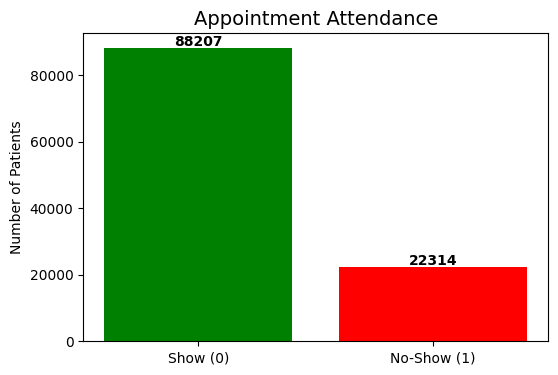

In [17]:
import matplotlib.pyplot as plt


counts = df_clean['NoShow'].value_counts()
print("Show (0):", counts[0])
print("No-Show (1):", counts[1])
print(f"\nNo-Show Rate: {counts[1] / (counts[0] + counts[1]) * 100:.2f}%")

# Bar plot
plt.figure(figsize=(6, 4))
plt.bar(['Show (0)', 'No-Show (1)'], counts.values, color=['green', 'red'])
plt.title('Appointment Attendance', fontsize=14)
plt.ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.show()

2 Age vs NoShow

Average age of patients who SHOWED UP: 37.8 years
Average age of patients who NO-SHOWED: 34.3 years
Difference: 3.5 years


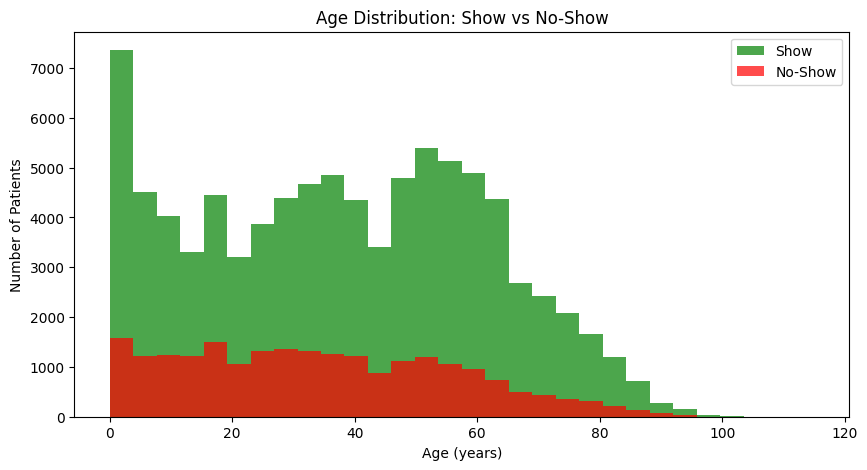

In [18]:

avg_age_show = df_clean[df_clean['NoShow'] == 0]['Age'].mean()
avg_age_noshow = df_clean[df_clean['NoShow'] == 1]['Age'].mean()

print(f"Average age of patients who SHOWED UP: {avg_age_show:.1f} years")
print(f"Average age of patients who NO-SHOWED: {avg_age_noshow:.1f} years")
print(f"Difference: {avg_age_show - avg_age_noshow:.1f} years")

#Create histogram
plt.figure(figsize=(10, 5))

# Show = green, No-Show = red
plt.hist(df_clean[df_clean['NoShow'] == 0]['Age'],
         bins=30, alpha=0.7, label='Show', color='green')

plt.hist(df_clean[df_clean['NoShow'] == 1]['Age'],
         bins=30, alpha=0.7, label='No-Show', color='red')

plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.title('Age Distribution: Show vs No-Show')
plt.legend()
plt.show()

Preparing Data For Machine Learning

In [19]:
# List all columns we have now
print("All columns in df_clean:")
print(df_clean.columns.tolist())

features = ['Gender_encoded', 'Age', 'Scholarship', 'Hypertension', 'Diabetes',
            'Alcoholism', 'Handcap', 'SMS_received', 'WaitingDays',
            ]


target = 'NoShow'

print(f"\nFeatures we'll use ({len(features)}):")
for f in features:
    print(f"  • {f}")

print(f"\nTarget: {target}")

All columns in df_clean:
['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show', 'NoShow', 'WaitingDays']

Features we'll use (9):
  • Gender_encoded
  • Age
  • Scholarship
  • Hypertension
  • Diabetes
  • Alcoholism
  • Handcap
  • SMS_received
  • WaitingDays

Target: NoShow


Converting Text of Gender Column to Binary Numbers

In [20]:

print("Before encoding:")
print(df_clean['Gender'].value_counts())


df_clean['Gender_encoded'] = df_clean['Gender'].map({'F': 0, 'M': 1})

print("\nAfter encoding:")
print(df_clean['Gender_encoded'].value_counts())


print("\nSample comparison:")
print(df_clean[['Gender', 'Gender_encoded']].head())

Before encoding:
Gender
F    71836
M    38685
Name: count, dtype: int64

After encoding:
Gender_encoded
0    71836
1    38685
Name: count, dtype: int64

Sample comparison:
  Gender  Gender_encoded
0      F               0
1      M               1
2      F               0
3      F               0
4      F               0


X= All of our Feature , Y=Target Variable aka NoShow

In [21]:
feature_column=['Gender_encoded','Age','Scholarship','Hypertension','Diabetes','Alcoholism','Handcap','SMS_received','WaitingDays']
X=df_clean[feature_column]
y=df_clean['NoShow']

print("Feature if Matrix X-Shape: ", X.shape)
print("Target Vector Y-Shape: ", y.shape)

print("First 5 rows of X:")
print(X.head())
print("First 5 values of y")
print(y.head())

Feature if Matrix X-Shape:  (110521, 9)
Target Vector Y-Shape:  (110521,)
First 5 rows of X:
   Gender_encoded  Age  Scholarship  Hypertension  Diabetes  Alcoholism  \
0               0   62            0             1         0           0   
1               1   56            0             0         0           0   
2               0   62            0             0         0           0   
3               0    8            0             0         0           0   
4               0   56            0             1         1           0   

   Handcap  SMS_received  WaitingDays  
0        0             0            0  
1        0             0            0  
2        0             0            0  
3        0             0            0  
4        0             0            0  
First 5 values of y
0    0
1    0
2    0
3    0
4    0
Name: NoShow, dtype: int64


Train Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  No-show rate: {y_train.mean():.2%}")

print("\nTesting set:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  No-show rate: {y_test.mean():.2%}")

Training set:
  X_train shape: (88416, 9)
  y_train shape: (88416,)
  No-show rate: 20.19%

Testing set:
  X_test shape: (22105, 9)
  y_test shape: (22105,)
  No-show rate: 20.19%


Handling the Class Imbalance Via the class Weights


In [23]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate weights automatically based on class distribution
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print("Class distribution in training data:")
print(f"  Show (0): {(y_train == 0).sum():,}")
print(f"  No-Show (1): {(y_train == 1).sum():,}")

print("\nClass weights:")
print(f"  Show (0): {class_weights[0]:.3f}")
print(f"  No-Show (1): {class_weights[1]:.3f}")

print("\nWhat this means:")
print(f"  Missing a NO-SHOW is {class_weights[1]/class_weights[0]:.1f}x more costly")
print(f"  → The model will try harder to catch no-shows")

Class distribution in training data:
  Show (0): 70,565
  No-Show (1): 17,851

Class weights:
  Show (0): 0.626
  No-Show (1): 2.476

What this means:
  Missing a NO-SHOW is 4.0x more costly
  → The model will try harder to catch no-shows


Training Model Via Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# Train the model
print("Training Logistic Regression...")
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Show', 'No-Show']))

Training Logistic Regression...

Accuracy: 0.6637 (66.37%)

Classification Report:
              precision    recall  f1-score   support

        Show       0.86      0.69      0.77     17642
     No-Show       0.31      0.56      0.40      4463

    accuracy                           0.66     22105
   macro avg       0.59      0.62      0.58     22105
weighted avg       0.75      0.66      0.69     22105



Now via Random Forest

In [25]:
# ============================================================
# Train Random Forest Model
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest with class weights
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 trees
    class_weight='balanced',
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Results
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Show', 'No-Show']))

Training Random Forest...

Accuracy: 0.6957 (69.57%)

Classification Report:
              precision    recall  f1-score   support

        Show       0.84      0.76      0.80     17642
     No-Show       0.31      0.42      0.36      4463

    accuracy                           0.70     22105
   macro avg       0.58      0.59      0.58     22105
weighted avg       0.73      0.70      0.71     22105



XGBOOST

In [26]:


import xgboost as xgb


scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_weight,  # Handle imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)


y_pred_xgb = xgb_model.predict(X_test)

# Results
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nAccuracy: {accuracy_xgb:.4f} ({accuracy_xgb*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Show', 'No-Show']))

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:31:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Accuracy: 0.5974 (59.74%)

Classification Report:
              precision    recall  f1-score   support

        Show       0.91      0.55      0.69     17642
     No-Show       0.31      0.78      0.44      4463

    accuracy                           0.60     22105
   macro avg       0.61      0.67      0.56     22105
weighted avg       0.79      0.60      0.64     22105



Comparing visually

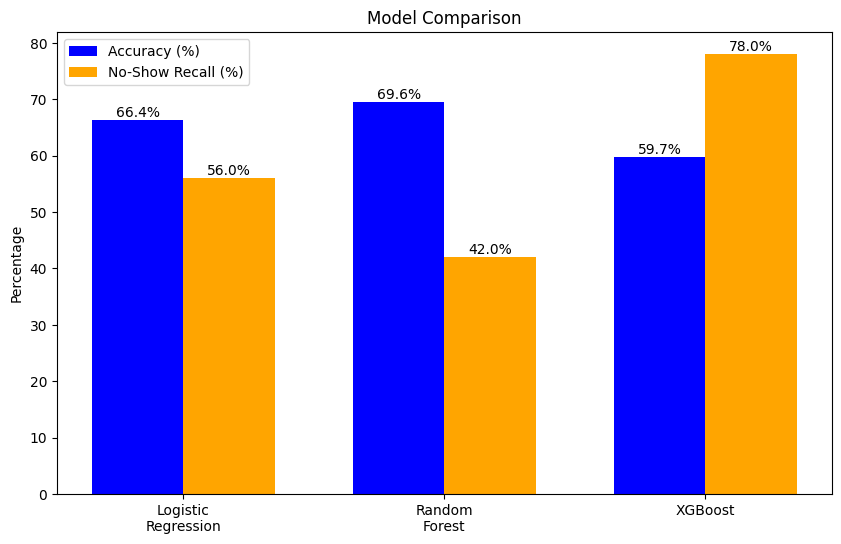

In [43]:


import matplotlib.pyplot as plt
import numpy as np

# Metrics for each model
models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
accuracy = [66.37, 69.57, 59.74]
no_show_recall = [56, 42, 78]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy (%)', color='blue')
bars2 = ax.bar(x + width/2, no_show_recall, width, label='No-Show Recall (%)', color='orange')

ax.set_ylabel('Percentage')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%',
            ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%',
            ha='center', va='bottom')

plt.show()

ROC-AUC of all three Models

📊 ROC-AUC SCORES
Logistic Regression: 0.6640
Random Forest:       0.6361
XGBoost:             0.7200


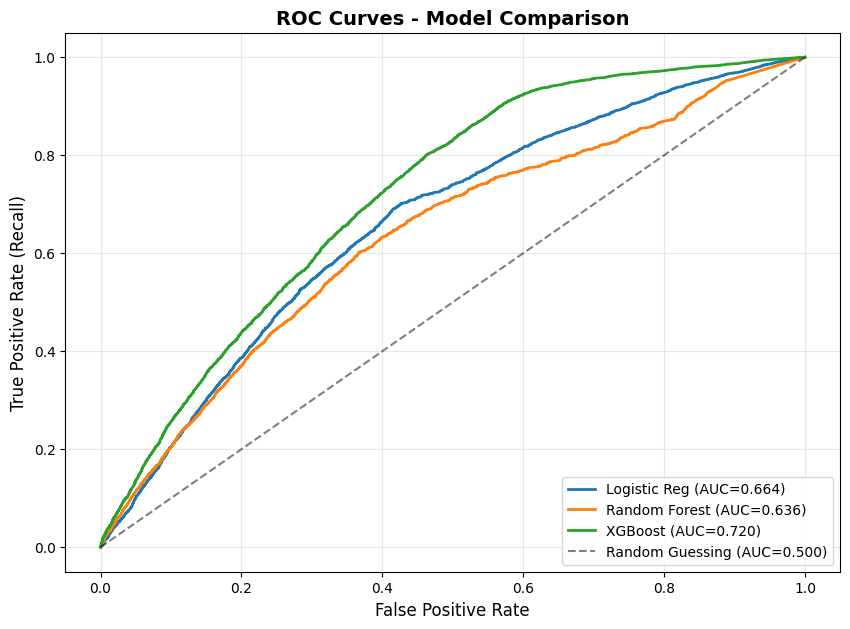

In [31]:


from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get prediction probabilities (not just 0/1)
y_prob_lr = model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
# Calculate AUC scores
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("=" * 50)
print("📊 ROC-AUC SCORES")
print("=" * 50)
print(f"Logistic Regression: {auc_lr:.4f}")
print(f"Random Forest:       {auc_rf:.4f}")
print(f"XGBoost:             {auc_xgb:.4f}")

# Plot ROC Curves
plt.figure(figsize=(10, 7))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={auc_lr:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})', linewidth=2)

# Random guessing line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC=0.500)', alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Which factor affects the NoShows Most

Feature Importance (XGBoost):
          Feature  Importance
8     WaitingDays    0.461323
1             Age    0.088667
7    SMS_received    0.080756
2     Scholarship    0.071824
0  Gender_encoded    0.070572
5      Alcoholism    0.070124
6         Handcap    0.061356
3    Hypertension    0.050371
4        Diabetes    0.045008


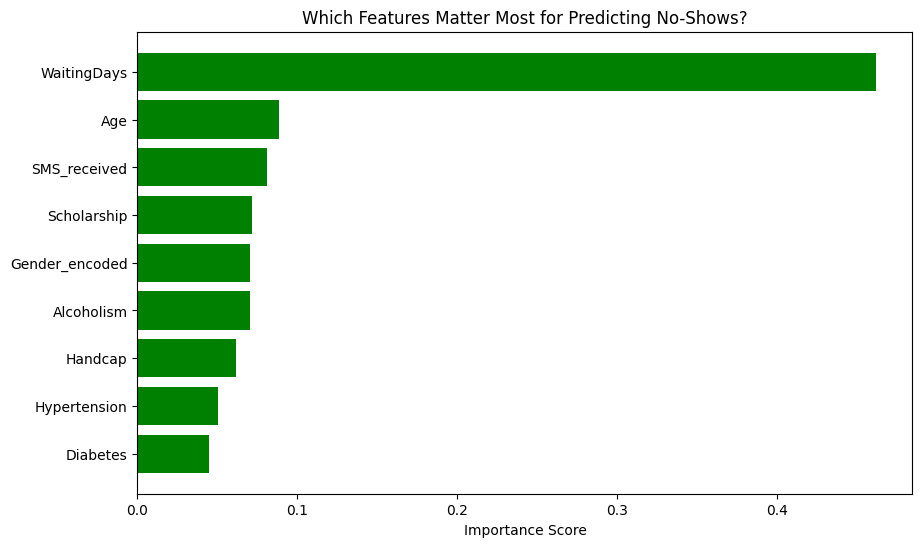

In [30]:


import matplotlib.pyplot as plt

# Get feature importance
importance = xgb_model.feature_importances_
features = X_train.columns

# Create DataFrame
feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("Feature Importance (XGBoost):")
print(feat_importance)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance['Feature'], feat_importance['Importance'], color='green')
plt.xlabel('Importance Score')
plt.title('Which Features Matter Most for Predicting No-Shows?')
plt.gca().invert_yaxis()  # Most important at top
plt.show()